# Real-Time Credit Card Fraud Detection & Risk Intelligence Platform

## Notebook 02 — Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the credit card transaction
dataset and identify important patterns, distributions, relationships, and
potential indicators of fraudulent transactions.

The analysis will focus on:

- Understanding the distribution of fraudulent and legitimate transactions
- Analyzing transaction amounts and customer spending behavior
- Studying temporal patterns in transactions
- Analyzing fraud across different categories and locations
- Understanding customer and merchant behavior
- Identifying potential features that may help in fraud detection

### Target Variable

The target variable is `is_fraud`.

- `0` → Legitimate transaction
- `1` → Fraudulent transaction

The findings from this analysis will guide the data cleaning,
feature engineering, and machine learning stages of the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fraudTest = pd.read_csv("fraudTest.csv")
fraudTest.head(1)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0


In [3]:
fraudTrain = pd.read_csv("fraudTrain.csv")
fraudTrain.head(1)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0


Target variable analysis


In [4]:
fraudTrain['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [5]:
fraudTrain['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

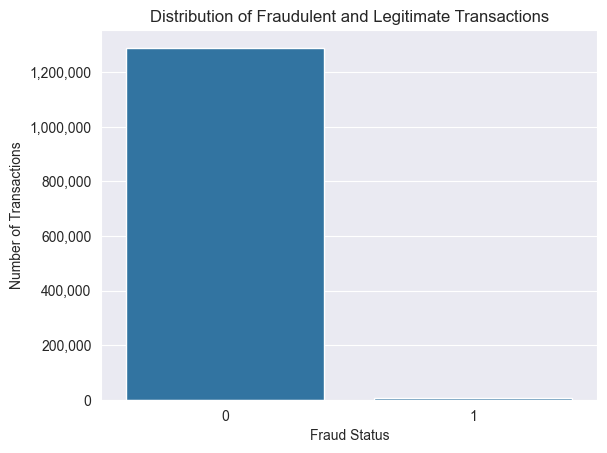

In [6]:
import matplotlib.ticker as ticker

sns.countplot(x=fraudTrain['is_fraud'])

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.xlabel('Fraud Status')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Fraudulent and Legitimate Transactions')

plt.show()


"The target variable is highly imbalanced because legitimate transactions significantly outnumber fraudulent transactions."

Transaction Amount analysis

In [7]:
fraudTrain['amt'].describe()

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

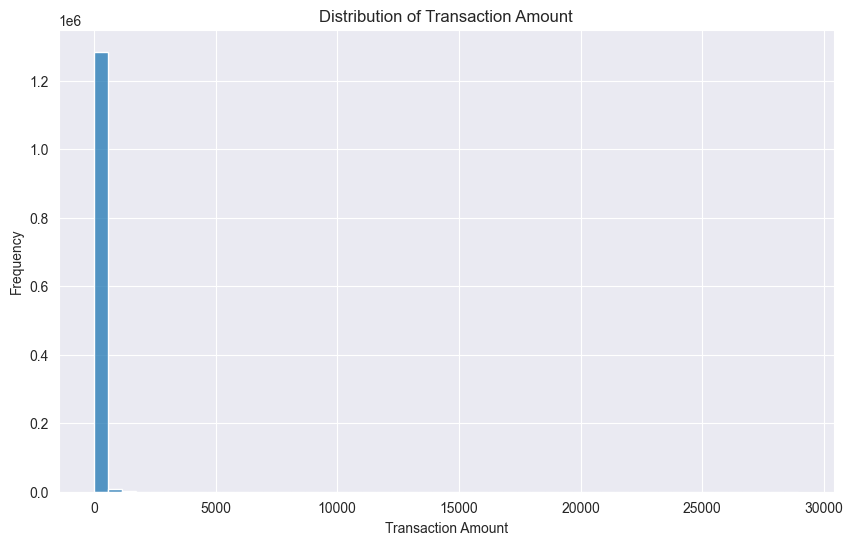

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=fraudTrain,
    x='amt',
    bins=50
)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

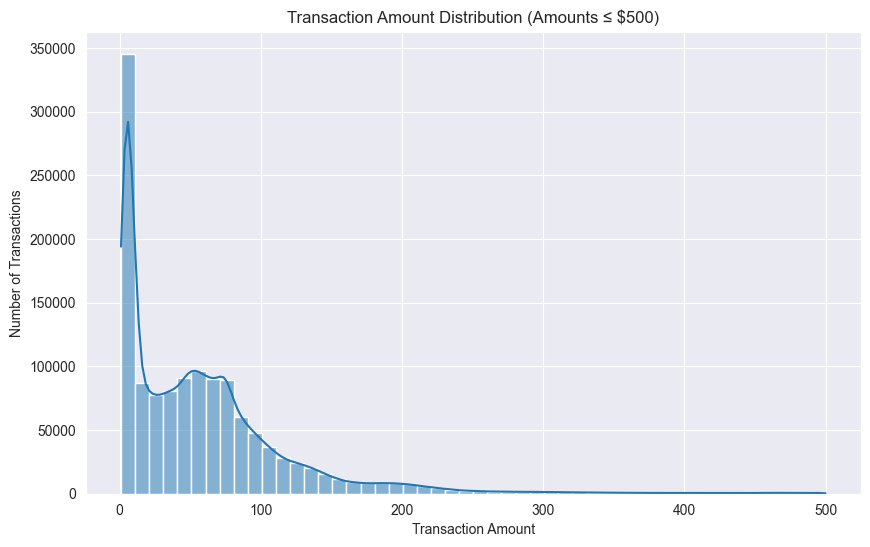

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    data = fraudTrain[fraudTrain['amt'] <= 500],
    x = 'amt',
    bins = 50,
    kde = True
)

plt.title('Transaction Amount Distribution (Amounts ≤ $500)')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')

plt.show()

Transaction amounts are highly right-skewed, with most transactions having relatively small amounts and a small number having very large amounts.

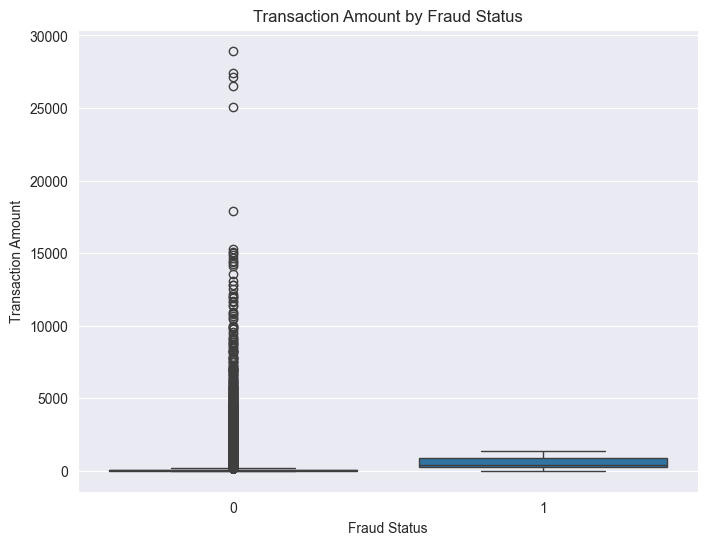

In [10]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=fraudTrain,
    x='is_fraud',
    y='amt'
)

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=fraudTrain[fraudTrain['amt'] <= 500],
    x='is_fraud',
    y='amt'
)

plt.title('Transaction Amount by Fraud Status (Amounts ≤ $500)')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')

plt.show()

In [16]:
fraudTrain.groupby('is_fraud')['amt'].mean()

is_fraud
0     67.667110
1    531.320092
Name: amt, dtype: float64

In [17]:
fraudTrain.groupby('is_fraud')['amt'].median()

is_fraud
0     47.280
1    396.505
Name: amt, dtype: float64

Time Analysis

Does the timing of a transaction have any relationship with fraud?

In [19]:
fraudTrain['trans_date_trans_time'] = pd.to_datetime(fraudTrain['trans_date_trans_time'])

In [20]:
fraudTrain['hour'] = (fraudTrain['trans_date_trans_time'].dt.hour)

In [21]:
fraudTrain['hour'].value_counts().sort_index()

hour
0     42502
1     42869
2     42656
3     42769
4     41863
5     42171
6     42300
7     42203
8     42505
9     42185
10    42271
11    42082
12    65257
13    65314
14    64885
15    65391
16    65726
17    65450
18    66051
19    65508
20    65098
21    65533
22    66982
23    67104
Name: count, dtype: int64

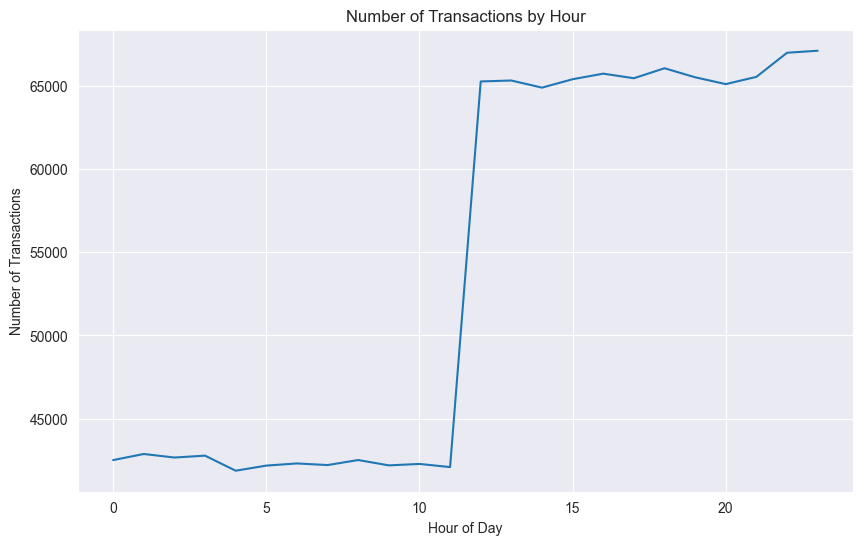

In [22]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=fraudTrain['hour'].value_counts().sort_index().index,
    y=fraudTrain['hour'].value_counts().sort_index().values
)

plt.title('Number of Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')

plt.show()

In [23]:
fraud_by_hour = (
    fraudTrain
    .groupby('hour')['is_fraud']
    .mean()
    * 100
)

In [24]:
fraud_by_hour

hour
0     1.494047
1     1.534909
2     1.465210
3     1.423929
4     0.109882
5     0.142278
6     0.094563
7     0.132692
8     0.115281
9     0.111414
10    0.094628
11    0.099805
12    0.102671
13    0.122485
14    0.132542
15    0.120812
16    0.115632
17    0.119175
18    0.122633
19    0.123649
20    0.095241
21    0.112920
22    2.882864
23    2.837387
Name: is_fraud, dtype: float64

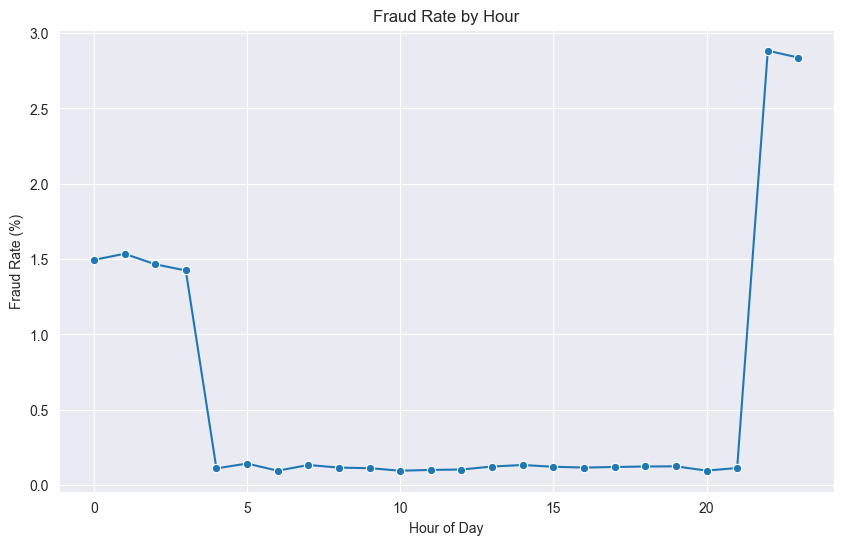

In [25]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values,
    marker='o'
)

plt.title('Fraud Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [26]:
fraudTrain['day_of_week'] = (
    fraudTrain['trans_date_trans_time'].dt.dayofweek
)

In [27]:
fraudTrain['day_of_week'].value_counts().sort_index()

day_of_week
0    254282
1    160227
2    131073
3    147285
4    152272
5    200957
6    250579
Name: count, dtype: int64

In [28]:
fraud_by_day = (
    fraudTrain
    .groupby('day_of_week')['is_fraud']
    .mean()
    * 100
)

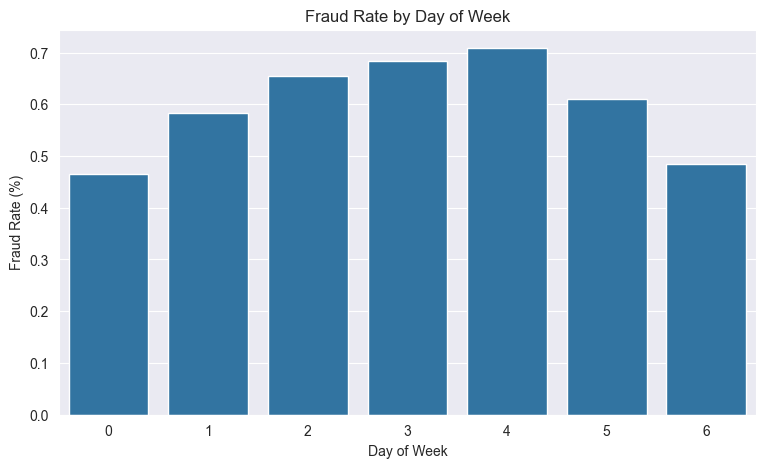

In [29]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=fraud_by_day.index,
    y=fraud_by_day.values
)

plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [33]:
fraudTrain['month'] = (
    fraudTrain['trans_date_trans_time'].dt.month
)

In [35]:
fraudTrain['month'].value_counts().sort_index()

month
1     104727
2      97657
3     143789
4     134970
5     146875
6     143811
7      86596
8      87359
9      70652
10     68758
11     70421
12    141060
Name: count, dtype: int64

In [34]:
fraud_by_month = (
    fraudTrain
    .groupby('month')['is_fraud']
    .mean()
    * 100
)

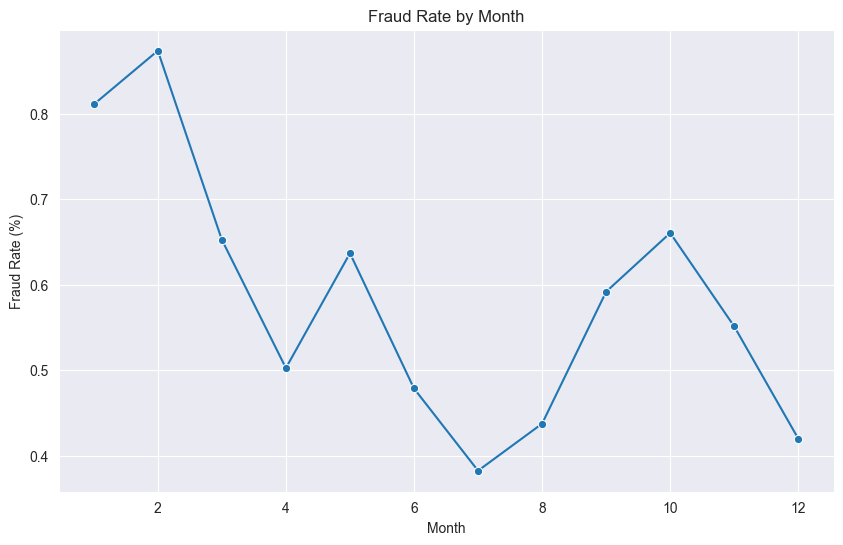

In [36]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=fraud_by_month.index,
    y=fraud_by_month.values,
    marker='o'
)

plt.title('Fraud Rate by Month')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')

plt.show()

Transaction Category Analysis

Does fraud behavior differ between different types of transactions?

In [37]:
fraudTrain['category'].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

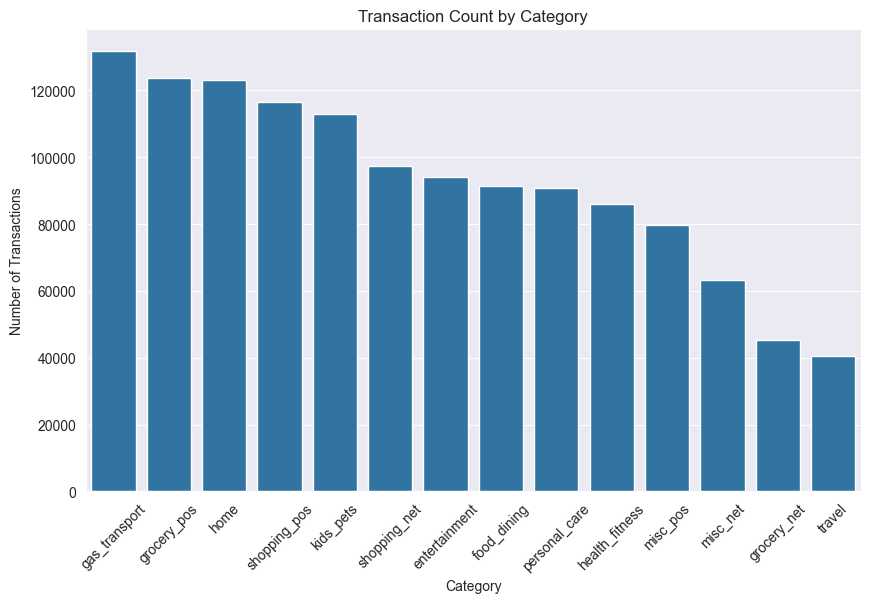

In [39]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=fraudTrain,
    x='category',
    order=fraudTrain['category'].value_counts().index
)

plt.xticks(rotation=45)

plt.title('Transaction Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')

plt.show()

In [40]:
fraud_by_category = (
    fraudTrain
    .groupby('category')['is_fraud']
    .mean()
    * 100
)

In [41]:
fraud_by_category.sort_values(ascending=False)

category
shopping_net      1.756149
misc_net          1.445795
grocery_pos       1.409761
shopping_pos      0.722538
gas_transport     0.469394
misc_pos          0.313853
grocery_net       0.294817
travel            0.286370
entertainment     0.247835
personal_care     0.242403
kids_pets         0.211439
food_dining       0.165098
home              0.160825
health_fitness    0.154869
Name: is_fraud, dtype: float64

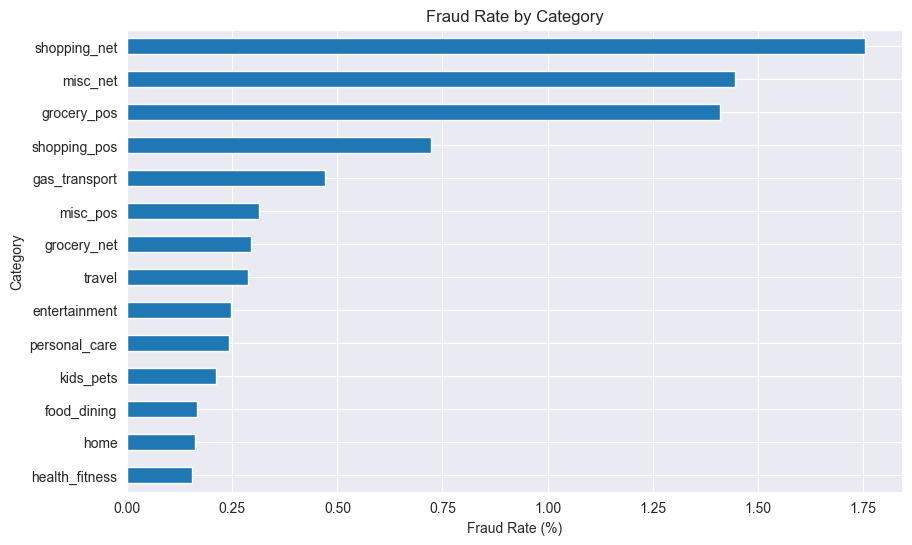

In [42]:
plt.figure(figsize=(10,6))

fraud_by_category.sort_values().plot(
    kind='barh'
)

plt.title('Fraud Rate by Category')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')

plt.show()

Customer/Card Behavior

Can a customer's transaction behavior provide useful information for detecting fraud?

In [43]:
fraudTrain['cc_num'].nunique()

983

In [44]:
transactions_per_card = (
    fraudTrain
    .groupby('cc_num')
    .size()
)

In [48]:
transactions_per_card

cc_num
60416207185            1518
60422928733            1531
60423098130             510
60427851591             528
60487002085             496
                       ... 
4958589671582726883    1476
4973530368125489546    1040
4980323467523543940     532
4989847570577635369    1007
4992346398065154184    2059
Length: 983, dtype: int64

In [45]:
transactions_per_card.describe()

count     983.000000
mean     1319.099695
std       812.235900
min         7.000000
25%       525.000000
50%      1054.000000
75%      2025.000000
max      3123.000000
dtype: float64

In [ ]:
y

In [46]:
avg_spending_per_card = (
    fraudTrain
    .groupby('cc_num')['amt']
    .mean()
)

In [49]:
avg_spending_per_card

cc_num
60416207185             56.023366
60422928733             69.000784
60423098130            115.046333
60427851591            111.987898
60487002085             50.726028
                          ...    
4958589671582726883     66.377839
4973530368125489546     78.373288
4980323467523543940     74.436429
4989847570577635369     87.582542
4992346398065154184     67.843832
Name: amt, Length: 983, dtype: float64

In [47]:
avg_spending_per_card.describe()

count    983.000000
mean     110.994666
std      146.595827
min       42.951671
25%       61.014479
50%       67.558216
75%       87.860569
max      948.818182
Name: amt, dtype: float64

Merchant Behaviour


In [50]:
fraudTrain['merchant'].nunique()

693

In [51]:
fraudTrain['merchant'].value_counts().head(10)

merchant
fraud_Kilback LLC                   4403
fraud_Cormier LLC                   3649
fraud_Schumm PLC                    3634
fraud_Kuhn LLC                      3510
fraud_Boyer PLC                     3493
fraud_Dickinson Ltd                 3434
fraud_Cummerata-Jones               2736
fraud_Kutch LLC                     2734
fraud_Olson, Becker and Koch        2723
fraud_Stroman, Hudson and Erdman    2721
Name: count, dtype: int64

In [52]:
fraud_by_merchant = (
    fraudTrain
    .groupby('merchant')['is_fraud']
    .mean()
    * 100
)

In [53]:
fraud_by_merchant.sort_values(ascending=False).head(10)

merchant
fraud_Kozey-Boehm                       2.572347
fraud_Herman, Treutel and Dickens       2.538462
fraud_Kerluke-Abshire                   2.230686
fraud_Brown PLC                         2.210884
fraud_Goyette Inc                       2.161606
fraud_Terry-Huel                        2.154309
fraud_Jast Ltd                          2.150538
fraud_Schmeler, Bashirian and Price     2.083333
fraud_Boyer-Reichert                    1.991614
fraud_Langworth, Boehm and Gulgowski    1.980701
Name: is_fraud, dtype: float64

GENDER / DEMOGRAPHIC ANALYSIS

In [54]:
fraudTrain['gender'].value_counts()

gender
F    709863
M    586812
Name: count, dtype: int64

In [55]:
fraud_by_gender = (
    fraudTrain
    .groupby('gender')['is_fraud']
    .mean()
    * 100
)

fraud_by_gender

gender
F    0.526158
M    0.642625
Name: is_fraud, dtype: float64

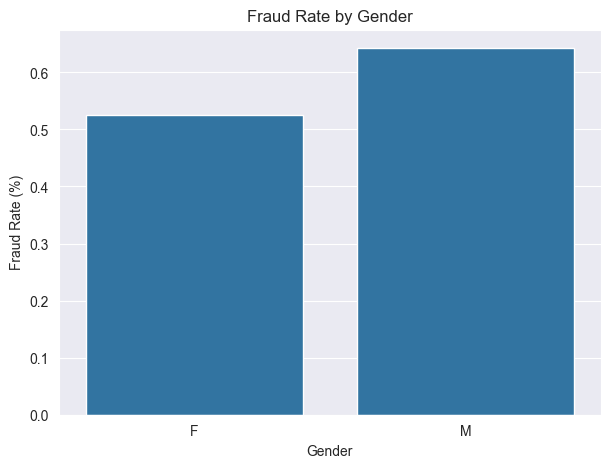

In [56]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=fraud_by_gender.index,
    y=fraud_by_gender.values
)

plt.title('Fraud Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate (%)')

plt.show()

AGE ANALYSIS


In [57]:
fraudTrain['dob'] = pd.to_datetime(fraudTrain['dob'])

In [58]:
fraudTrain['age'] = (
    fraudTrain['trans_date_trans_time'].dt.year
    - fraudTrain['dob'].dt.year
)

In [59]:
fraudTrain['age'].describe()

count    1.296675e+06
mean     4.602930e+01
std      1.738237e+01
min      1.400000e+01
25%      3.300000e+01
50%      4.400000e+01
75%      5.700000e+01
max      9.600000e+01
Name: age, dtype: float64

In [60]:
fraud_by_age = (
    fraudTrain
    .groupby('age')['is_fraud']
    .mean()
    * 100
)

In [61]:
fraud_by_age.head()

age
14    0.531108
15    0.275056
16    0.724922
17    0.000000
18    1.486798
Name: is_fraud, dtype: float64

GEOGRAPHIC ANALYSIS

In [62]:
fraudTrain['state'].value_counts().head(10)

state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
Name: count, dtype: int64

In [64]:
fraud_by_state = (
    fraudTrain
    .groupby('state')['is_fraud']
    .mean()
    * 100
)

fraud_by_state.sort_values(ascending=False).head(10)

state
DE    100.000000
RI      2.727273
AK      1.698113
NV      0.838238
CO      0.814121
OR      0.801204
TN      0.797539
NE      0.744786
ME      0.720994
NH      0.712733
Name: is_fraud, dtype: float64

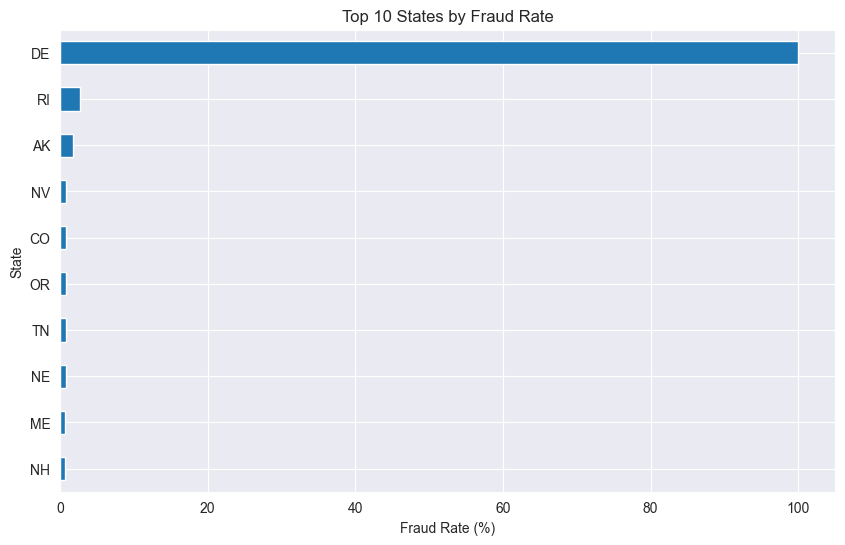

In [65]:
plt.figure(figsize=(10,6))

fraud_by_state.sort_values(ascending=False).head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 States by Fraud Rate')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('State')

plt.show()

02_exploratory_data_analysis.ipynb

│
├── 1. Target Variable Analysis
│     └── is_fraud distribution


├── 2. Transaction Amount Analysis
│     ├── describe()
│     ├── histogram
│     ├── boxplot
│     ├── mean
│     └── median


├── 3. Time Analysis
│     ├── hour
│     ├── fraud rate by hour
│     ├── day of week
│     └── month
│
├── 4. Category Analysis
│     ├── category counts
│     └── fraud rate by category


├── 5. Customer/Card Behavior
│     ├── unique cards
│     ├── transactions per card
│     └── average spending per card


├── 6. Merchant Behavior
│     ├── unique merchants
│     ├── transaction volume
│     └── fraud rate


├── 7. Demographic Analysis
│     ├── gender
│     └── age


├── 8. Geographic Analysis
│     └── state


└── 9. EDA Findings